# Exploratory Data Analysis (EDA) - Dataset de ortopedia
Este notebook contem todo o processo de exploração de dados da base de dados fornecida "ML_Ortopedia_CPAK" de forma a entender a estrutura, distribuições, relacões e identificar potenciais padrões para desenvolver um modelo de Machine learning
## 1. Visão geral dos dados e informação básica

In [2]:
%matplotlib inline

# importar dados como dataframe
import pandas as pd

ortho = pd.read_excel('ML_Ortopedia_CPAK.xlsx')

In [3]:
# verificar estrutura do dataframe
ortho.shape

(265, 22)

In [4]:
#verificar as primeiras linhas do dataframe
ortho.head()

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WAtotal_0,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação
0,67,1,80,158,32.046146,5.0,5,86,4,324,...,54,75,80,1,290,5,1,9,15,8
1,76,2,60,155,24.973985,5.0,5,90,4,357,...,39,60,110,1,480,5,4,3,12,9
2,72,2,93,182,28.076319,1.0,1,45,10,289,...,53,72,100,0,388,0,0,0,0,10
3,67,2,71,163,26.722873,6.0,6,127,2,390,...,16,18,100,0,387,2,0,10,12,9
4,66,1,49,160,19.140625,6.0,6,120,0,285,...,8,8,125,1,284,0,1,2,3,7


In [5]:
# ver os tipos de dados do dataframe
ortho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Idade       265 non-null    int64  
 1   Sexo        265 non-null    int64  
 2   Peso        265 non-null    int64  
 3   Altura_cm   265 non-null    int64  
 4   IMC         265 non-null    float64
 5   Grupo_pre   262 non-null    float64
 6   Grupo_pos   265 non-null    int64  
 7   Fle_0       265 non-null    int64  
 8   EVA_0       265 non-null    int64  
 9   PM6_0       265 non-null    int64  
 10  WD_0        265 non-null    int64  
 11  WR_0        265 non-null    int64  
 12  WAtotal_0   265 non-null    int64  
 13  WT_0        265 non-null    int64  
 14  Fle_90      265 non-null    int64  
 15  EVA_90      265 non-null    int64  
 16  PM6_90      265 non-null    int64  
 17  WD_90       265 non-null    int64  
 18  WR_90       265 non-null    int64  
 19  WAtotal_90  265 non-null    i

In [6]:
# verificar se existem linhas duplicadas
ortho.duplicated().sum()

np.int64(0)

In [7]:
#verificação de valores nulos
ortho.isnull().sum()

Idade         0
Sexo          0
Peso          0
Altura_cm     0
IMC           0
Grupo_pre     3
Grupo_pos     0
Fle_0         0
EVA_0         0
PM6_0         0
WD_0          0
WR_0          0
WAtotal_0     0
WT_0          0
Fle_90        0
EVA_90        0
PM6_90        0
WD_90         0
WR_90         0
WAtotal_90    0
WT_90         0
Satisfação    0
dtype: int64

**2.Transformação dos dados**

Transformação da base de dados original para facilitar a análise

In [8]:
#visualizar os casos que possuem valores nulos, listando por linha 
missing_values = ortho[ortho['Grupo_pre'].isnull()]
missing_values

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WAtotal_0,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação
259,67,1,76,160,29.687500,NaN,2,150,3,480,...,23,36,123,0,460,0,6,12,18,9
260,73,1,71,153,30.330215,NaN,8,92,8,220,...,41,57,115,1,340,1,1,16,18,10
261,77,2,63,161,24.304618,NaN,4,130,7,160,...,44,59,110,0,280,0,1,6,7,10


In [9]:
# eliminar os casos com valores nulos, pois são poucos e não devem impactar a análise
ortho = ortho.dropna(subset = ['Grupo_pre'])
          

In [10]:
# verificar novamente a presença de valores nulos
ortho.isnull().sum()

Idade         0
Sexo          0
Peso          0
Altura_cm     0
IMC           0
Grupo_pre     0
Grupo_pos     0
Fle_0         0
EVA_0         0
PM6_0         0
WD_0          0
WR_0          0
WAtotal_0     0
WT_0          0
Fle_90        0
EVA_90        0
PM6_90        0
WD_90         0
WR_90         0
WAtotal_90    0
WT_90         0
Satisfação    0
dtype: int64

In [11]:
# conversão do tipo de "grupo_pre" para int64
ortho['Grupo_pre'] = ortho['Grupo_pre'].astype('int64')

In [12]:
# substituição da codificação da variavel 'Sexo' por outros valores numéricos para não induzir o modelo em erro hierárquico, 
# onde o valor 2 (masculino) seria considerado maior que o valor 1 (feminino), o que não é o caso. 
# original 1: feminino, 2: masculino
# nova codificação 0: feminino, 1: masculino

ortho.replace({'Sexo': {1: 0, 2: 1}}, inplace = True)

In [13]:
# gerar a variavel de interesse "mudanca_CPAK" que indica se houve mudança no grupo de classificação entre o pré e o pós-operatório.
ortho['mudanca_CPAK'] = (ortho['Grupo_pre'] != ortho['Grupo_pos']).astype(int)

In [14]:
# verificar o numero de linhas e de colunas após a limpeza dos dados
ortho.shape

(262, 23)

In [15]:
# verificar os tipos de variaveis 
ortho.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262 entries, 0 to 264
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Idade         262 non-null    int64  
 1   Sexo          262 non-null    int64  
 2   Peso          262 non-null    int64  
 3   Altura_cm     262 non-null    int64  
 4   IMC           262 non-null    float64
 5   Grupo_pre     262 non-null    int64  
 6   Grupo_pos     262 non-null    int64  
 7   Fle_0         262 non-null    int64  
 8   EVA_0         262 non-null    int64  
 9   PM6_0         262 non-null    int64  
 10  WD_0          262 non-null    int64  
 11  WR_0          262 non-null    int64  
 12  WAtotal_0     262 non-null    int64  
 13  WT_0          262 non-null    int64  
 14  Fle_90        262 non-null    int64  
 15  EVA_90        262 non-null    int64  
 16  PM6_90        262 non-null    int64  
 17  WD_90         262 non-null    int64  
 18  WR_90         262 non-null    int64

In [16]:
# avaliar consistencia dos dados, verificando se existem valores fora do esperado para cada variavel
ortho.describe()

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação,mudanca_CPAK
count,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,...,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,71.133588,0.362595,84.377863,169.038168,36.565258,4.595420,4.309160,116.858779,28.309160,263.759542,...,48.538168,112.667939,16.767176,315.606870,2.729008,1.270992,10.740458,14.740458,46.633588,0.099237
std,7.658498,0.481669,81.752397,73.659921,84.693225,1.581883,1.683772,97.667192,148.909188,130.702931,...,16.005880,79.091249,122.551933,108.510827,2.455551,1.286177,7.969855,10.269613,190.084704,0.299552
min,47.000000,0.000000,32.000000,136.000000,14.222222,1.000000,1.000000,10.000000,0.000000,0.000000,...,8.000000,70.000000,0.000000,121.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,66.000000,0.000000,66.250000,155.000000,26.147508,4.000000,3.000000,95.000000,4.000000,180.000000,...,37.250000,95.000000,0.000000,249.000000,1.000000,0.000000,5.000000,8.000000,8.000000,0.000000
50%,72.000000,0.000000,76.000000,162.000000,28.725735,5.000000,5.000000,110.000000,6.000000,253.500000,...,47.000000,105.000000,1.000000,300.000000,2.000000,1.000000,9.000000,13.000000,10.000000,0.000000
75%,76.000000,1.000000,86.750000,170.000000,32.015277,6.000000,5.000000,120.000000,8.000000,330.000000,...,59.000000,116.000000,3.000000,360.000000,4.000000,2.000000,15.000000,20.000000,10.000000,0.000000
max,89.000000,1.000000,999.000000,999.000000,999.000000,9.000000,9.000000,999.000000,999.000000,999.000000,...,96.000000,999.000000,999.000000,999.000000,11.000000,8.000000,40.000000,55.000000,999.000000,1.000000


In [17]:
# converter todos os 999 para NaN, estão fora de contexto e 
# podem ser erros de introdução de dados/missing values.

import numpy as np
ortho.replace(999, np.nan, inplace=True)

In [18]:
# verificação de valores nulos - trocou-se os 999 por NaN, 
# agora é possível verificar a quantidade de valores nulos em cada coluna. 
ortho.isnull().sum()

Idade            0
Sexo             0
Peso             2
Altura_cm        2
IMC              2
Grupo_pre        0
Grupo_pos        0
Fle_0            3
EVA_0            6
PM6_0            3
WD_0             0
WR_0             0
WAtotal_0        1
WT_0             0
Fle_90           2
EVA_90           4
PM6_90           2
WD_90            0
WR_90            0
WAtotal_90       0
WT_90            0
Satisfação      10
mudanca_CPAK     0
dtype: int64

In [19]:
#verificar novamente as estatisticas descritivas após a conversão dos 999 para NaN
ortho.describe()


,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação,mudanca_CPAK
count,262.000000,262.000000,260.000000,260.000000,260.000000,262.000000,262.000000,259.000000,256.000000,259.000000,...,262.000000,260.000000,258.000000,260.000000,262.000000,262.000000,262.000000,262.000000,252.00000,262.000000
mean,71.133588,0.362595,77.342308,162.653846,29.161914,4.595420,4.309160,106.640927,5.558594,255.243243,...,48.538168,105.850000,1.538760,310.350000,2.729008,1.270992,10.740458,14.740458,8.84127,0.099237
std,7.658498,0.481669,15.021803,10.371264,4.534809,1.581883,1.683772,22.281463,2.387156,104.514560,...,16.005880,13.812192,1.968737,90.727075,2.455551,1.286177,7.969855,10.269613,1.49854,0.299552
min,47.000000,0.000000,32.000000,136.000000,14.222222,1.000000,1.000000,10.000000,0.000000,0.000000,...,8.000000,70.000000,0.000000,121.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,66.000000,0.000000,66.000000,155.000000,26.115156,4.000000,3.000000,95.000000,4.000000,180.000000,...,37.250000,95.000000,0.000000,249.000000,1.000000,0.000000,5.000000,8.000000,8.00000,0.000000
50%,72.000000,0.000000,76.000000,161.500000,28.715101,5.000000,5.000000,110.000000,6.000000,249.000000,...,47.000000,104.000000,1.000000,300.000000,2.000000,1.000000,9.000000,13.000000,9.00000,0.000000
75%,76.000000,1.000000,86.000000,170.000000,31.896222,6.000000,5.000000,120.000000,7.250000,327.000000,...,59.000000,116.000000,2.750000,360.000000,4.000000,2.000000,15.000000,20.000000,10.00000,0.000000
max,89.000000,1.000000,137.000000,198.000000,42.324275,9.000000,9.000000,150.000000,10.000000,522.000000,...,96.000000,153.000000,8.000000,600.000000,11.000000,8.000000,40.000000,55.000000,10.00000,1.000000


In [20]:
# report profile do dataframe ortho 
# from pandas_profiling import ProfileReport
# profile = ProfileReport(ortho, title="Pandas Profiling Report", explorative=True)
# profile.to_file("pandas_profiling_report_.html")

In [21]:
# transformar valores de variavel WR_0>8 em nan
ortho.loc[ortho['WR_0'] > 8, 'WR_0'] = np.nan

In [22]:
# imputar valores missing de WR_0,Fle_0, EVA_0 e PM6_0 utilizando a mediana
ortho['Fle_0'].fillna(ortho['Fle_0'].median(), inplace=True)
ortho['EVA_0'].fillna(ortho['EVA_0'].median(), inplace=True)
ortho['PM6_0'].fillna(ortho['PM6_0'].median(), inplace=True)
ortho['WR_0'].fillna(ortho['WR_0'].median(), inplace=True)

C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\393556532.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ortho['Fle_0'].fillna(ortho['Fle_0'].median(), inplace=True)
C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\393556532.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [23]:
ortho.isnull().sum()

Idade            0
Sexo             0
Peso             2
Altura_cm        2
IMC              2
Grupo_pre        0
Grupo_pos        0
Fle_0            0
EVA_0            0
PM6_0            0
WD_0             0
WR_0             0
WAtotal_0        1
WT_0             0
Fle_90           2
EVA_90           4
PM6_90           2
WD_90            0
WR_90            0
WAtotal_90       0
WT_90            0
Satisfação      10
mudanca_CPAK     0
dtype: int64

In [24]:
# verificar os casos que ainda possuem valores nulos, listando por linha
ortho[ortho['IMC'].isnull()]

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação,mudanca_CPAK
53,73,0,NaN,NaN,NaN,5,5,98.0,6.0,109.0,...,53,111.0,1.0,232.0,0,0,8,8,8.0,0
75,65,1,NaN,NaN,NaN,2,2,130.0,7.0,288.0,...,45,110.0,2.0,277.0,0,1,5,6,10.0,0


In [25]:
# os casos com valor nulo de IMC possuem também valores nulos de peso e altura, 
# não é possivel calcular o IMC sem essas informações, sendo lógico imputar a mediana nesses dois casos
# sem mexer nas variaveis peso e altura

ortho['IMC'].fillna(ortho['IMC'].median(), inplace=True) 

C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\3105577449.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ortho['IMC'].fillna(ortho['IMC'].median(), inplace=True)


In [26]:
# corrigir o missing value de WAtotal com calculo WATotal = WT - (WR + WD)
missing_WA_0 = ortho[ortho['WAtotal_0'].isnull()] 
missing_WA_0['WAtotal_0'] = (missing_WA_0['WT_0']- (missing_WA_0['WR_0'] + missing_WA_0['WD_0']))
missing_WA_0 


C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\2043347205.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_WA_0['WAtotal_0'] = (missing_WA_0['WT_0']- (missing_WA_0['WR_0'] + missing_WA_0['WD_0']))


,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação,mudanca_CPAK
202,72,0,72.0,155.0,29.968783,4,4,100.0,5.0,10.0,...,33,90.0,5.0,250.0,6,4,23,33,6.0,0


In [27]:
# verificar uma ultima vez a presença de valores nulos 
ortho.isnull().sum()    

Idade            0
Sexo             0
Peso             2
Altura_cm        2
IMC              0
Grupo_pre        0
Grupo_pos        0
Fle_0            0
EVA_0            0
PM6_0            0
WD_0             0
WR_0             0
WAtotal_0        1
WT_0             0
Fle_90           2
EVA_90           4
PM6_90           2
WD_90            0
WR_90            0
WAtotal_90       0
WT_90            0
Satisfação      10
mudanca_CPAK     0
dtype: int64

## EDA

Depois de limpar os dados importa começar a exploração dos dados propriamente dita. 

In [28]:
# verificar a quantidade de casos em cada categoria da variavel de interesse "mudanca_CPAK"
# em valores absolutos e relativos
tabela_mudanca_CPAK = (
    pd.concat(
        [
            ortho["mudanca_CPAK"].value_counts(dropna=False),
            ortho["mudanca_CPAK"].value_counts(normalize=True, dropna=False).mul(100).round(2)
        ],
        axis=1
        )
)

tabela_mudanca_CPAK.columns = ["Frequencia_Absoluta", "Frequencia_Relativa_%"]
tabela_mudanca_CPAK

,Frequencia_Absoluta,Frequencia_Relativa_%
mudanca_CPAK,,
0,236,90.08
1,26,9.92


In [29]:
# criação de cópia de dataframe para analise exploratória 
ortho_eda = ortho.copy()
# 

In [30]:
# criação de variaveis dummies para as variáveis categóricas,numéricas e target

var_numericas = list(ortho_eda[["IMC","Fle_0","EVA_0","PM6_0","WR_0","WAtotal_0"]].columns)
var_categoricas = list(ortho_eda[["Sexo","Grupo_pre","Grupo_pos"]].columns)


### Comparação estatística das variáveis numéricas por classe (mudanca_CPAK)

Para cada variável numérica, compara-se a **mediana** e o **IQR** entre as classes 0 (sem mudança) e 1 (com mudança), e aplica-se o **teste de Mann-Whitney U** para verificar se as diferenças observadas nos boxplots são estatisticamente significativas.

In [38]:
from scipy.stats import mannwhitneyu

results = []
for var in var_numericas:
    for classe in [0, 1]:
        grupo = ortho_eda[ortho_eda['mudanca_CPAK'] == classe][var].dropna()
        q1 = grupo.quantile(0.25)
        q3 = grupo.quantile(0.75)
        results.append({
            'Variável': var,
            'Classe': classe,
            'Mediana': round(grupo.median(), 2),
            'IQR': round(q3 - q1, 2),
            'Q1': round(q1, 2),
            'Q3': round(q3, 2),
            'N': len(grupo)
        })

df_stats = pd.DataFrame(results)
df_stats_pivot = df_stats.pivot(index='Variável', columns='Classe', values=['N', 'Mediana', 'IQR', 'Q1', 'Q3'])
df_stats_pivot.columns = [f'{stat}_classe{cls}' for stat, cls in df_stats_pivot.columns]

# Teste Mann-Whitney U
mw_results = []
for var in var_numericas:
    g0 = ortho_eda[ortho_eda['mudanca_CPAK'] == 0][var].dropna()
    g1 = ortho_eda[ortho_eda['mudanca_CPAK'] == 1][var].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    mw_results.append({'Variável': var, 'U_statistic': round(stat, 2), 'p_value': round(p, 4), 'Significativo (p<0.05)': p < 0.05})

df_mw = pd.DataFrame(mw_results).set_index('Variável')
df_final = df_stats_pivot.join(df_mw)
df_final

,N_classe0,N_classe1,Mediana_classe0,Mediana_classe1,IQR_classe0,IQR_classe1,Q1_classe0,Q1_classe1,Q3_classe0,Q3_classe1,U_statistic,p_value,Significativo (p<0.05)
Variável,,,,,,,,,,,,,
EVA_0,236.0,26.0,6.00,5.50,3.00,3.50,4.00,3.50,7.00,7.00,3153.0,0.8161,False
Fle_0,236.0,26.0,110.00,120.00,28.00,26.75,92.00,106.25,120.00,133.00,1908.0,0.0015,True
IMC,236.0,26.0,28.87,25.56,5.33,7.02,26.67,23.87,32.01,30.89,3998.5,0.0112,True
PM6_0,236.0,26.0,242.50,350.50,132.25,151.50,177.75,267.00,310.00,418.50,1437.5,0.0000,True
WAtotal_0,235.0,26.0,34.00,30.50,18.00,17.50,26.00,24.25,44.00,41.75,3507.0,0.2162,False
WR_0,236.0,26.0,3.00,3.00,2.00,1.75,2.00,2.25,4.00,4.00,2700.0,0.3095,False


C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\3063615294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ortho_eda, x='mudanca_CPAK', y=var, palette={'0': 'lightcoral', '1': 'limegreen'}, ax=ax)
C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\3063615294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ortho_eda, x='mudanca_CPAK', y=var, palette={'0': 'lightcoral', '1': 'limegreen'}, ax=ax)
C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\3063615294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ortho_e

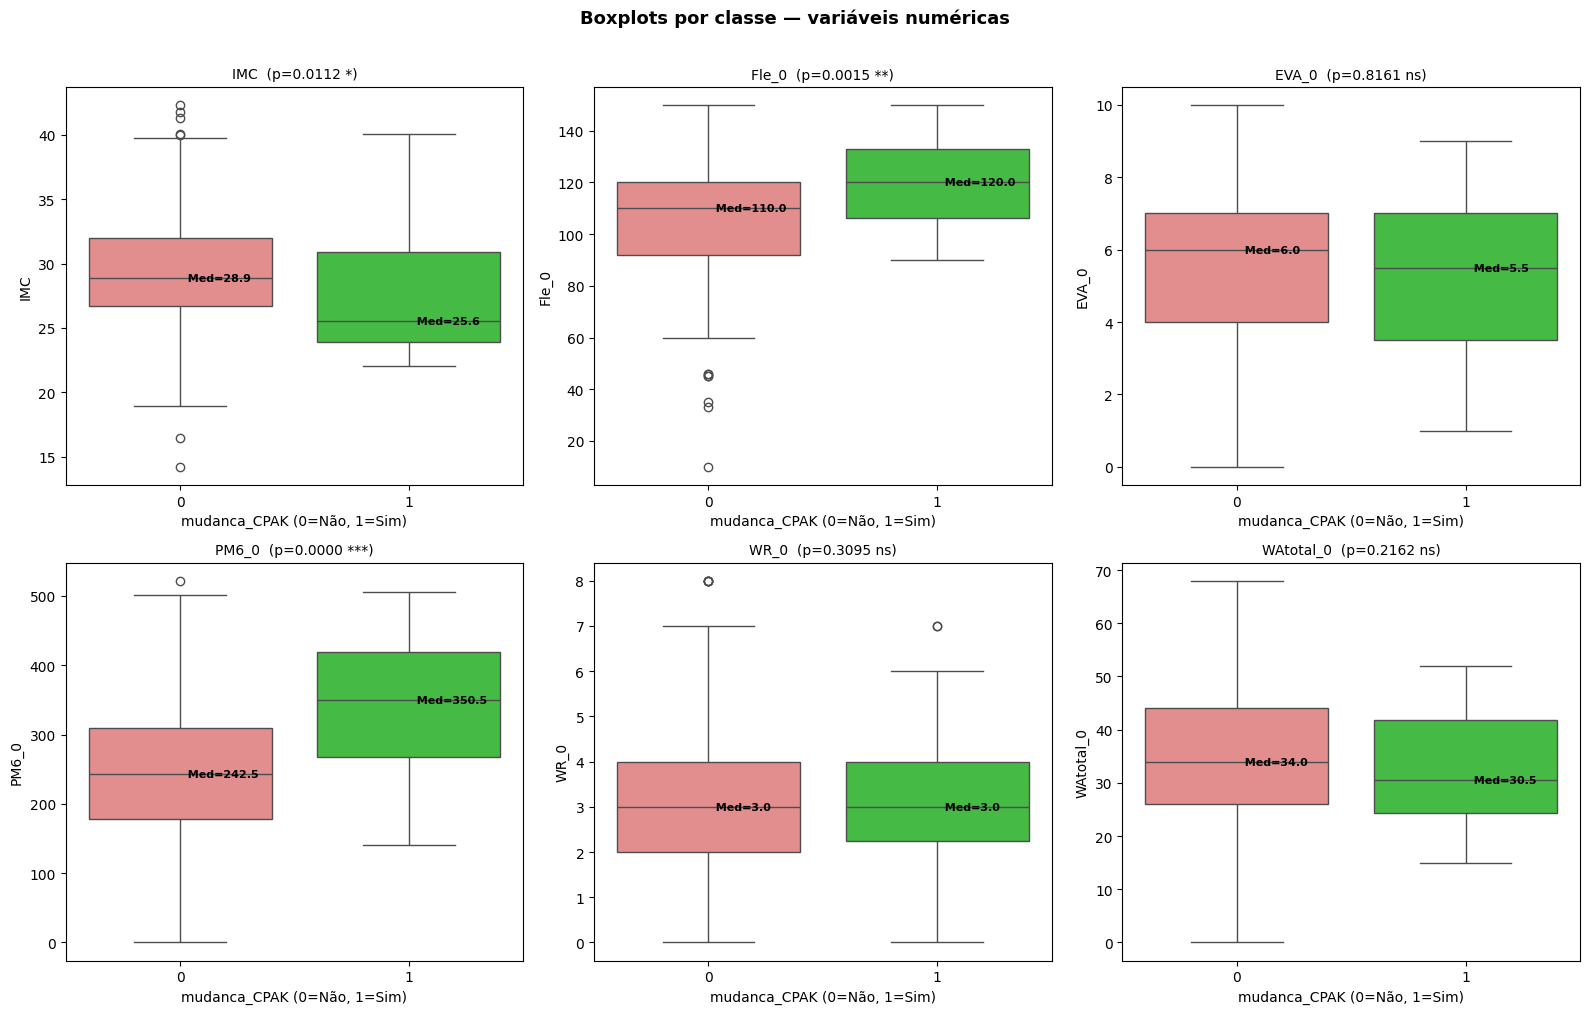

In [42]:
# Boxplots com anotação da mediana por classe
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(var_numericas):
    ax = axes[i]
    sns.boxplot(data=ortho_eda, x='mudanca_CPAK', y=var, palette={'0': 'lightcoral', '1': 'limegreen'}, ax=ax)
    
    for classe, x_pos in zip([0, 1], [0, 1]):
        med = ortho_eda[ortho_eda['mudanca_CPAK'] == classe][var].median()
        ax.text(x_pos, med, f'  Med={med:.1f}', va='center', fontsize=8, color='black', fontweight='bold')
    
    # adicionar p-value no título
    p = df_mw.loc[var, 'p_value']
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(f'{var}  (p={p:.4f} {sig})', fontsize=10)
    ax.set_xlabel('mudanca_CPAK (0=Não, 1=Sim)')

plt.suptitle('Boxplots por classe — variáveis numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close()

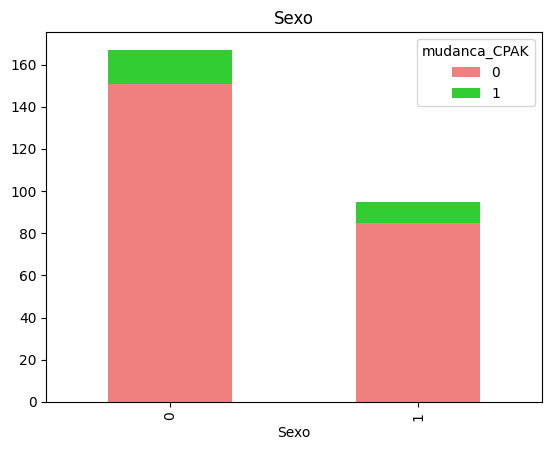

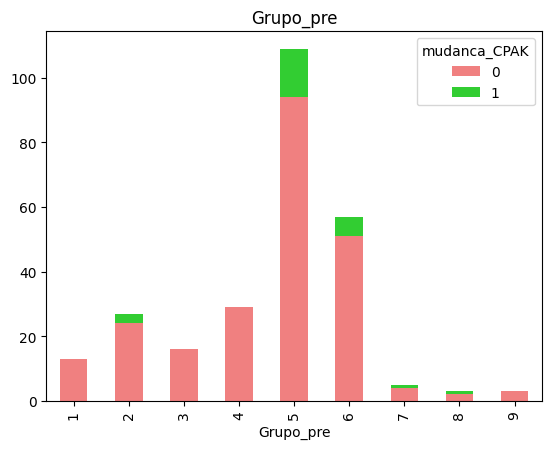

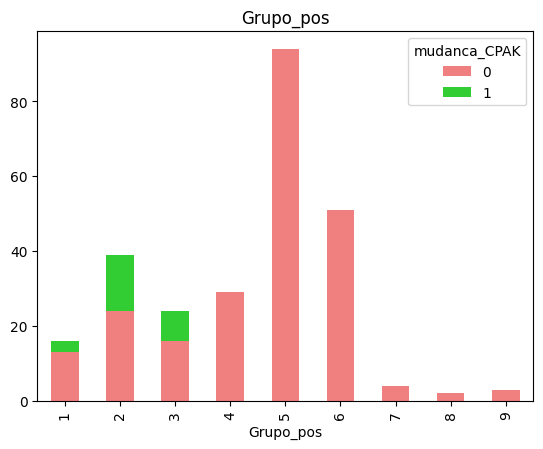

In [32]:
# gráficos de barras para as variáveis categóricas em relação à variável de interesse "mudanca_CPAK"
for var in var_categoricas:
    pd.crosstab(ortho_eda[var], ortho_eda['mudanca_CPAK']).plot(kind='bar', stacked=True, color=['lightcoral', 'limegreen'])
    plt.title(var)
    plt.show()
    plt.close()

C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\1817275904.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


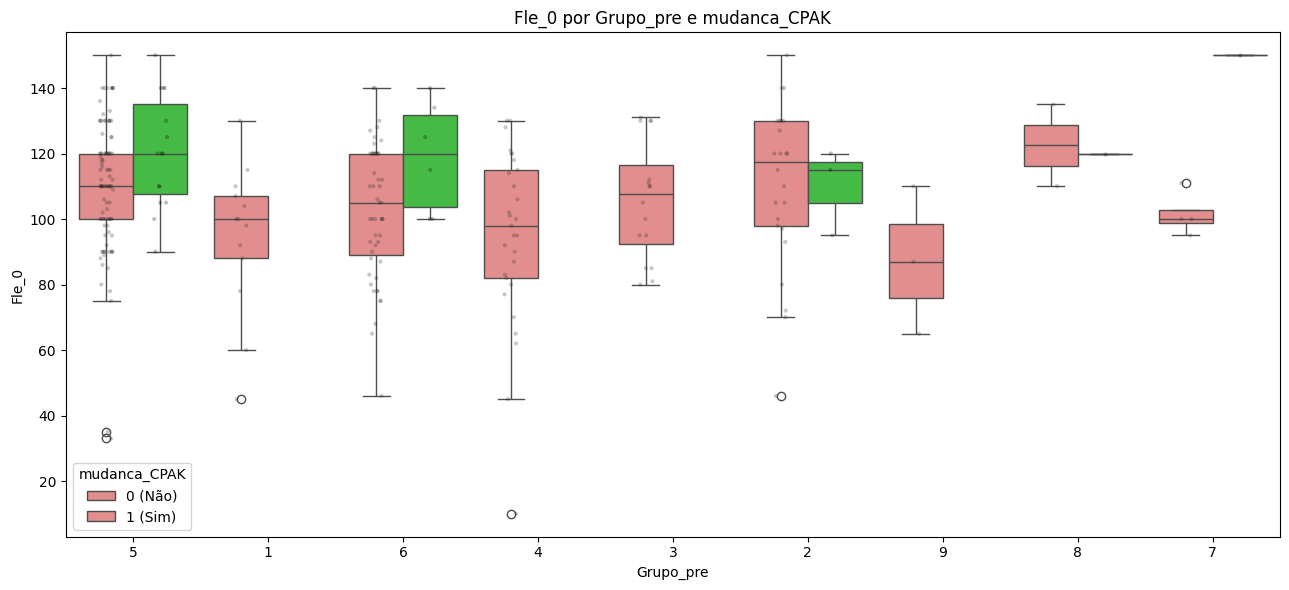

# análise de correlações e redundância

In [57]:
# separação de datasets retirando as variáveis que causam data leakage
# (variaveis que reportam valores pós-operatórios)

ortho_eda_clean = ortho_eda.drop(columns = [
    'Grupo_pos','Fle_90','EVA_90','PM6_90','WD_90','WR_90','WAtotal_90',
    'WT_90', 'Satisfação'
    ]
    )



In [58]:
#analise de correlação entre as variaveis numéricas e target

ortho_eda_clean.corr(method = 'spearman')

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Fle_0,EVA_0,PM6_0,WD_0,WR_0,WAtotal_0,WT_0,mudanca_CPAK
Idade,1.000000,-0.017705,-0.179192,-0.161411,-0.112676,-0.103372,-0.101746,0.060025,-0.279752,-0.067015,-0.086941,0.067295,0.025671,-0.159920
Sexo,-0.017705,1.000000,0.418570,0.678689,-0.020995,-0.142504,0.203692,-0.161417,0.307819,-0.148563,-0.149042,-0.168538,-0.175139,0.015203
Peso,-0.179192,0.418570,1.000000,0.552278,0.744703,-0.131173,0.024013,-0.064862,0.202509,0.013060,-0.026678,0.010686,0.009126,-0.069041
Altura_cm,-0.161411,0.678689,0.552278,1.000000,-0.097204,-0.061849,0.115715,-0.148432,0.401924,-0.084293,-0.018557,-0.146594,-0.126651,0.125252
IMC,-0.112676,-0.020995,0.744703,-0.097204,1.000000,-0.120144,-0.065405,0.052682,-0.073337,0.081627,0.002424,0.125034,0.112081,-0.157062
Grupo_pre,-0.103372,-0.142504,-0.131173,-0.061849,-0.120144,1.000000,0.042595,0.008382,0.037226,-0.016993,-0.027459,0.061782,0.050702,0.107998
Fle_0,-0.101746,0.203692,0.024013,0.115715,-0.065405,0.042595,1.000000,-0.269893,0.325783,-0.242705,-0.261073,-0.322780,-0.337659,0.196197
EVA_0,0.060025,-0.161417,-0.064862,-0.148432,0.052682,0.008382,-0.269893,1.000000,-0.360230,0.500606,0.207957,0.497083,0.524326,-0.014481
PM6_0,-0.279752,0.307819,0.202509,0.401924,-0.073337,0.037226,0.325783,-0.360230,1.000000,-0.289503,-0.111640,-0.373735,-0.359095,0.275251
WD_0,-0.067015,-0.148563,0.013060,-0.084293,0.081627,-0.016993,-0.242705,0.500606,-0.289503,1.000000,0.309120,0.687961,0.775629,-0.031026


<Axes: >

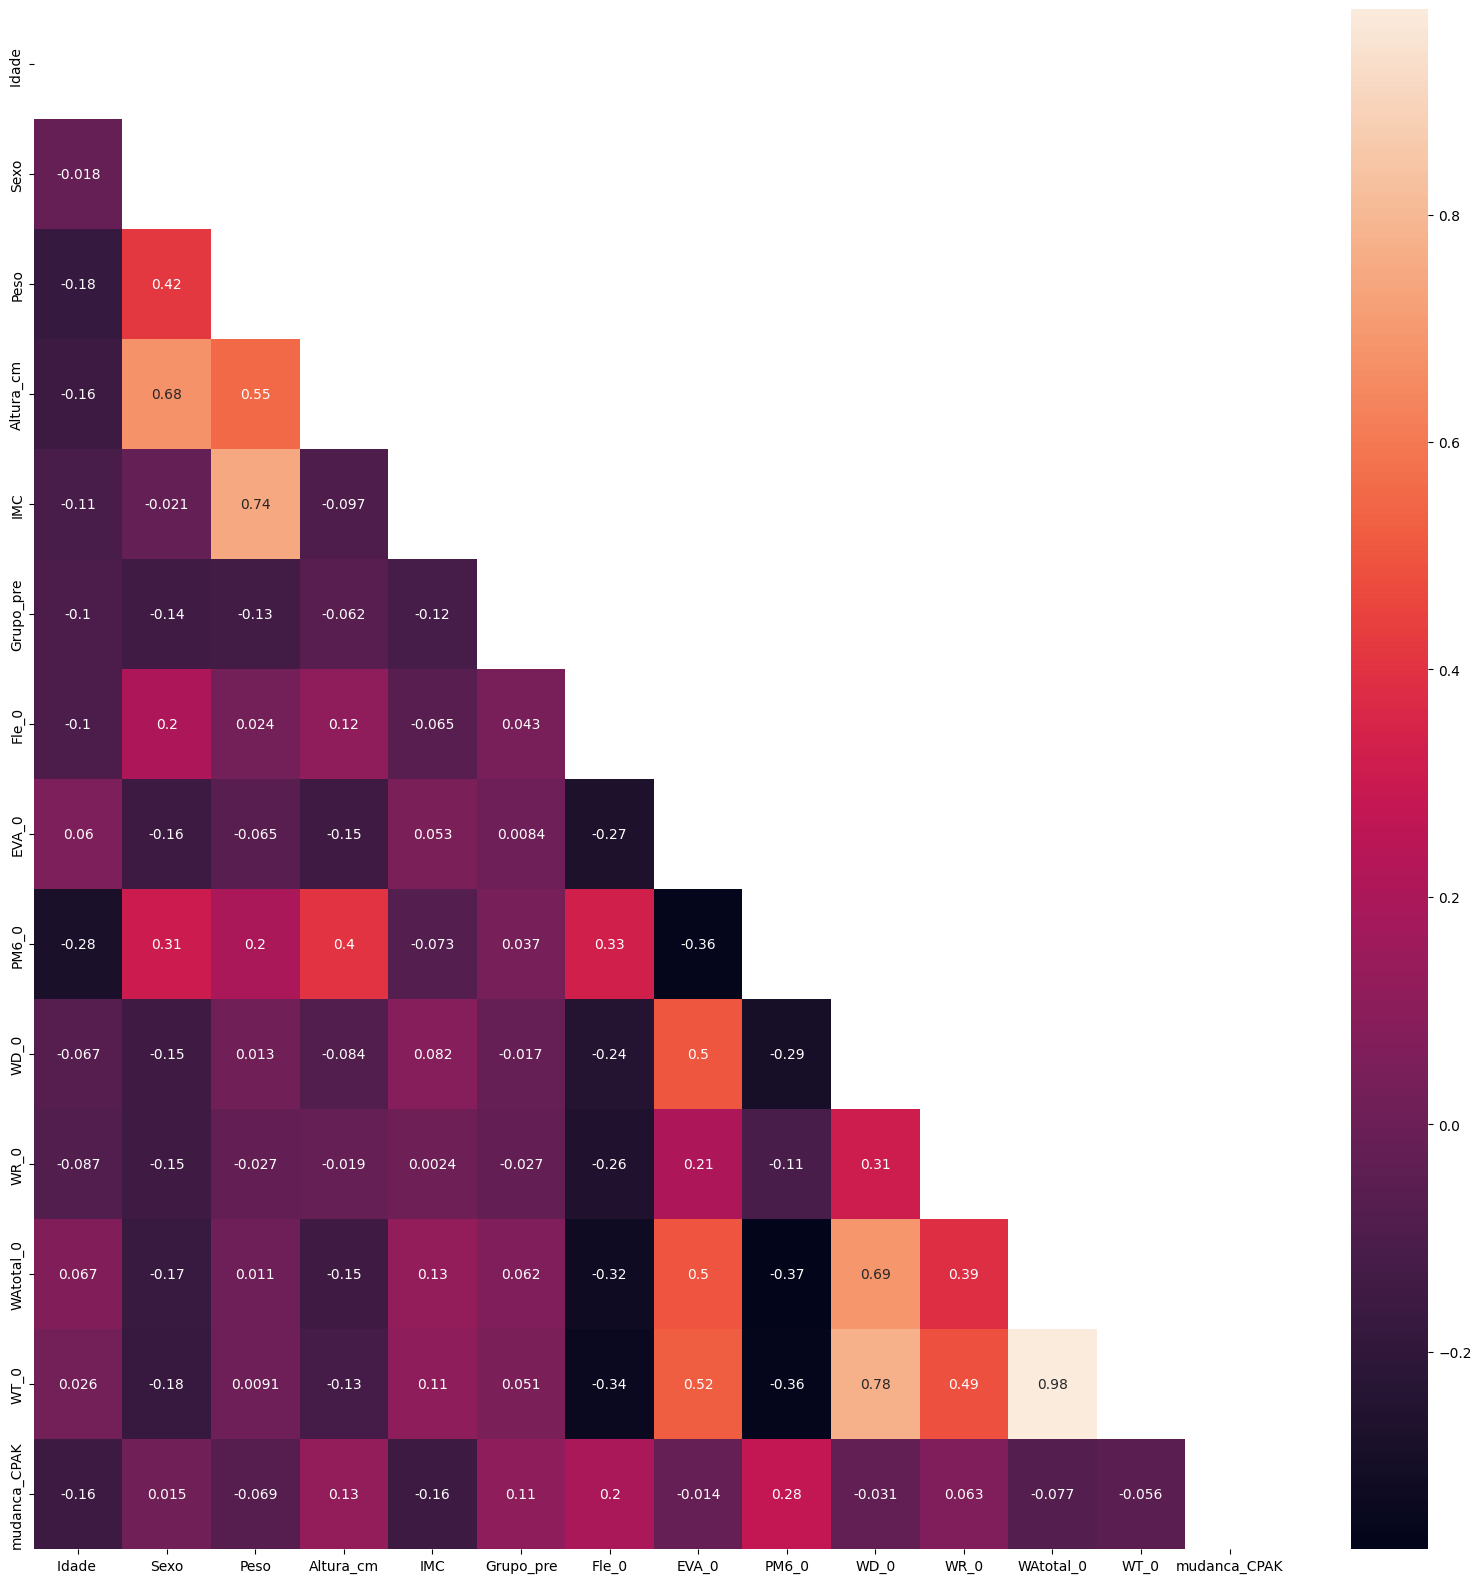

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
matrix = np.triu(ortho_eda_clean.corr(method='spearman'))

plt.figure(figsize=(20,20))
sns.heatmap(ortho_eda_clean.corr(method='spearman'), annot=True, mask=matrix)

<Axes: >

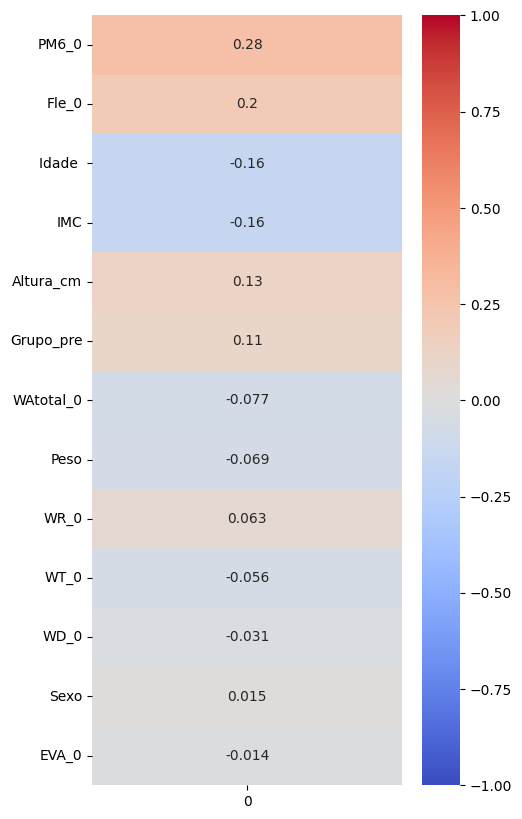

In [ ]:
# gráfico de correlações com a target (variável dependente)
correlations = ortho_eda_clean.corrwith(ortho_eda_clean['mudanca_CPAK'], method='spearman').iloc[:-1].to_frame()
correlations['abs'] = correlations[0].abs()
sorted_correlations = correlations.sort_values('abs', ascending=False)[0]

fig,ax = plt.subplots(figsize=(5,10))
sns.heatmap(sorted_correlations.to_frame(), cmap='coolwarm', annot=True, vmin=-1, vmax=1, ax=ax)

C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\368546044.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


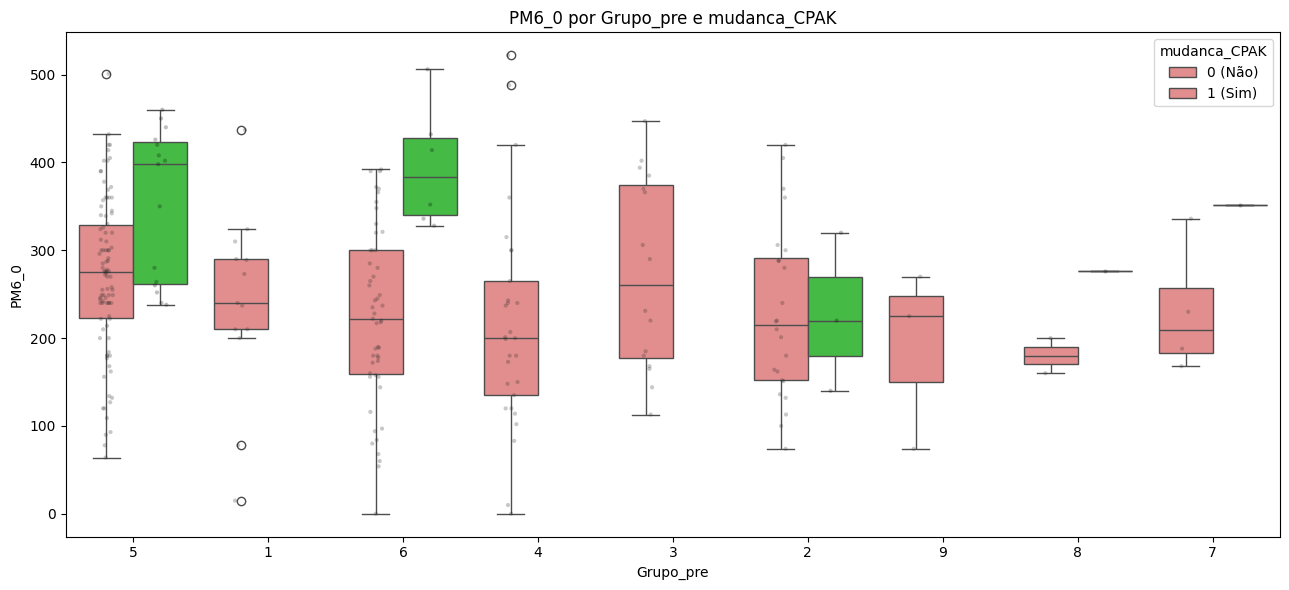

In [60]:
# relação entre Grupo_pre, PM6_0 e mudanca_CPAK
plot_df = ortho_eda[['Grupo_pre', 'PM6_0', 'mudanca_CPAK']].dropna().copy()
plot_df['Grupo_pre'] = plot_df['Grupo_pre'].astype(int).astype(str)
plot_df['mudanca_CPAK'] = plot_df['mudanca_CPAK'].astype(int).astype(str)

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=plot_df,
    x='Grupo_pre',
    y='PM6_0',
    hue='mudanca_CPAK',
    palette={'0': 'lightcoral', '1': 'limegreen'}
)

sns.stripplot(
    data=plot_df,
    x='Grupo_pre',
    y='PM6_0',
    hue='mudanca_CPAK',
    dodge=True,
    alpha=0.25,
    size=3,
    color='black',
    legend=False
)

plt.title('PM6_0 por Grupo_pre e mudanca_CPAK')
plt.xlabel('Grupo_pre')
plt.ylabel('PM6_0')
plt.legend(title='mudanca_CPAK', labels=['0 (Não)', '1 (Sim)'])
plt.tight_layout()
plt.show()
plt.close()

C:\Users\Eduardo\AppData\Local\Temp\ipykernel_27260\1817275904.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


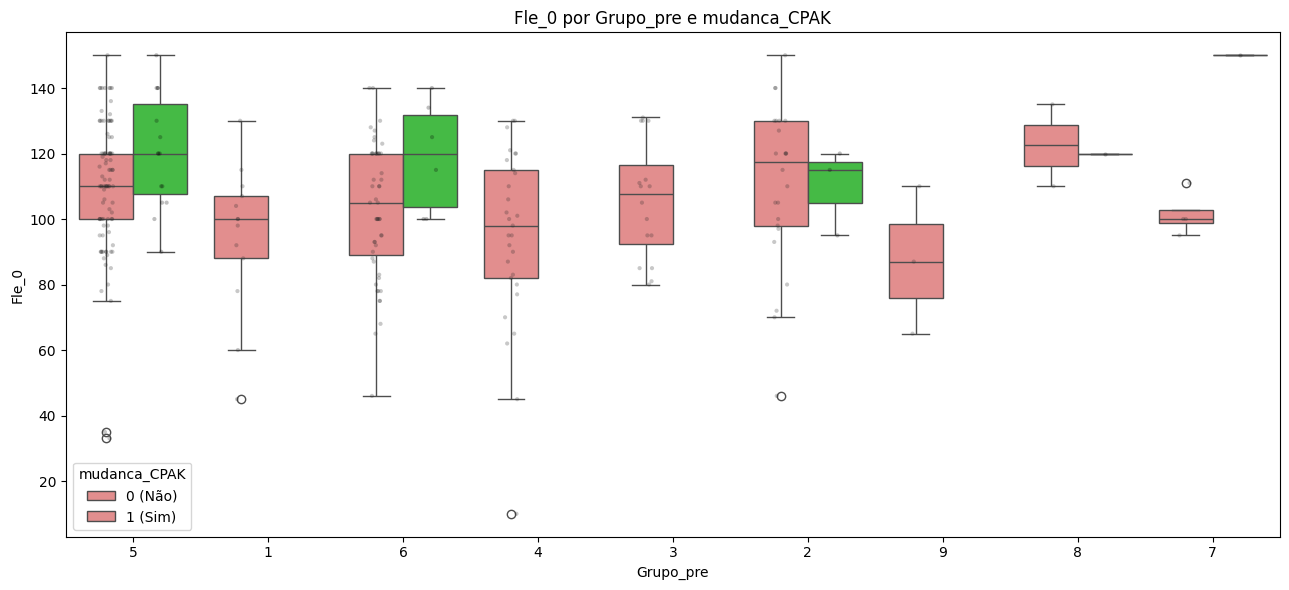

In [61]:
# relação entre Grupo_pre, Fle_0 e mudanca_CPAK
plot_df = ortho_eda[['Grupo_pre', 'Fle_0', 'mudanca_CPAK']].dropna().copy()
plot_df['Grupo_pre'] = plot_df['Grupo_pre'].astype(int).astype(str)
plot_df['mudanca_CPAK'] = plot_df['mudanca_CPAK'].astype(int).astype(str)

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=plot_df,
    x='Grupo_pre',
    y='Fle_0',
    hue='mudanca_CPAK',
    palette={'0': 'lightcoral', '1': 'limegreen'}
)

sns.stripplot(
    data=plot_df,
    x='Grupo_pre',
    y='Fle_0',
    hue='mudanca_CPAK',
    dodge=True,
    alpha=0.25,
    size=3,
    color='black',
    legend=False
)

plt.title('Fle_0 por Grupo_pre e mudanca_CPAK')
plt.xlabel('Grupo_pre')
plt.ylabel('Fle_0')
plt.legend(title='mudanca_CPAK', labels=['0 (Não)', '1 (Sim)'])
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
ortho_eda_sem_WT = ortho_eda.drop(columns = ['Grupo_pos','Fle_90','EVA_90','PM6_90','WD_90','WR_90','WAtotal_90',
    'WT_90', 'Satisfação','WT_0'])
ortho_eda_sem_componentes = ortho_eda.drop(columns = [
    'WD_0','WR_0','WAtotal_0','Grupo_pos','Fle_90','EVA_90','PM6_90','WD_90','WR_90','WAtotal_90',
    'WT_90', 'Satisfação'
])